#Capstone Project

## Submission Guideline

- Your jupyter notebook(s)

## The Use Case
#### **This a financial Dataset from a bank in Europe, and consists of 8 CSV files. Descriptions of which are as follows. You are provided a data set (in csv format) containing the following data**


**Account (4500 Observations)** - Each record describes static characteristics of an account

**Client (5369 Observations)** - Each record describes characteristics of a client

**Disposition (5369 Observations)** - Each record relates together a client with an account (*relationship.csv*)

**Order (6471 Observations)** - Each record describes characteristics of a payment order

**Transaction (1056320 Observations)** - Each record describes one transaction on an account

**Loan (682 Observations)** - Each record describes a loan granted for a given account

**Credit card (892 Observations)** - Each record describes a credit card issued to an account

**Demographic data (77 Observations)** - Each record describes demographic characteristics of a district.

### ER Diagram for the Dataset
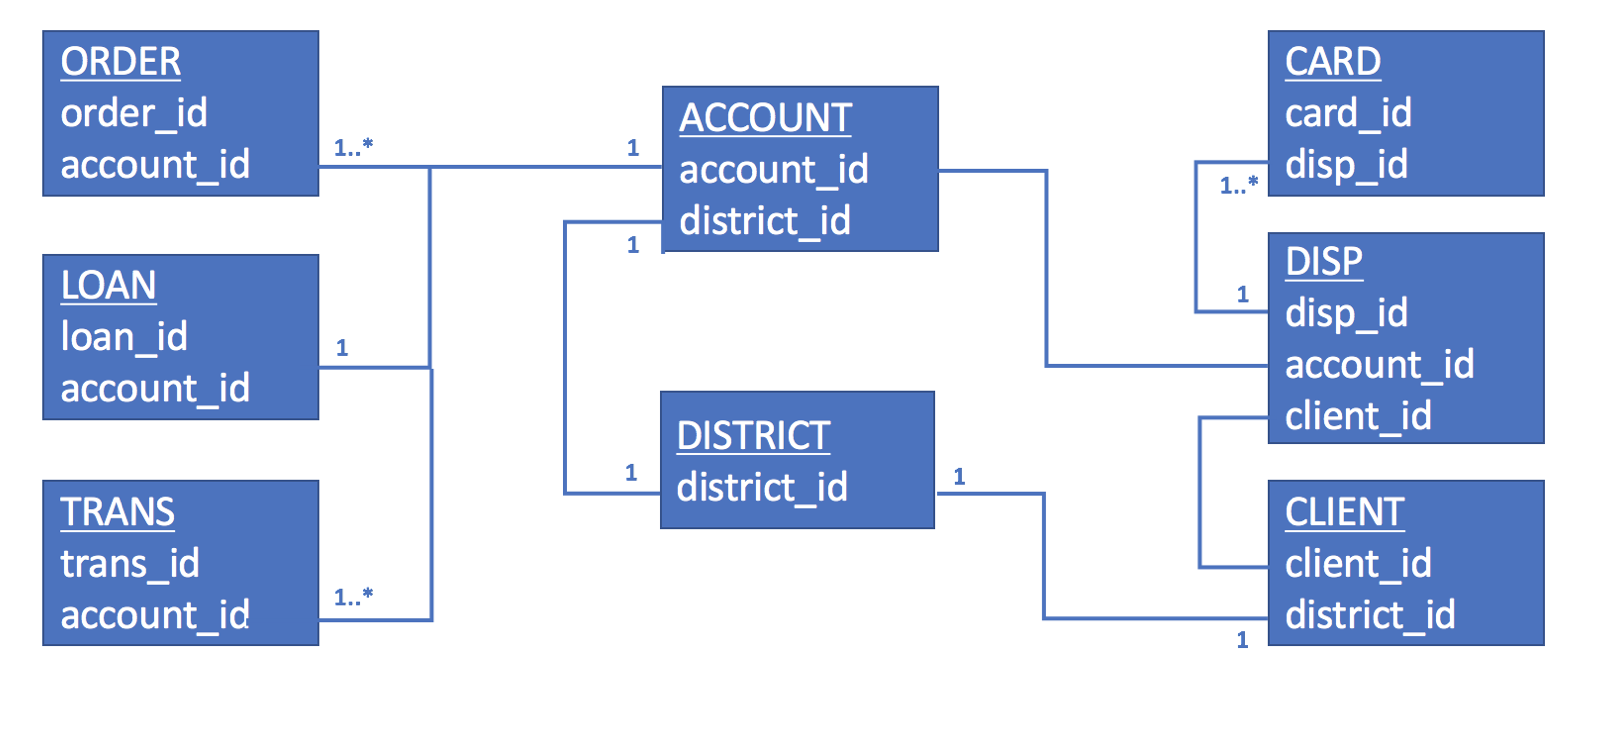

### 1. Load the *'csv'* files into Spark DataFrames, show the complete build process in your notebook.
- Change the column names and data types, if required.

In [165]:
#Creating spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

In [166]:
#Load client.csv (1)
df_client = spark.read.csv(
    "/content/data/client.csv",
    header=True,
    inferSchema=True,
    sep=';'
)

df_client.show()
df_client.printSchema()

+---------+------------+-----------+
|client_id|birth_number|district_id|
+---------+------------+-----------+
|        1|      706213|         18|
|        2|      450204|          1|
|        3|      406009|          1|
|        4|      561201|          5|
|        5|      605703|          5|
|        6|      190922|         12|
|        7|      290125|         15|
|        8|      385221|         51|
|        9|      351016|         60|
|       10|      430501|         57|
|       11|      505822|         57|
|       12|      810220|         40|
|       13|      745529|         54|
|       14|      425622|         76|
|       15|      185828|         21|
|       16|      190225|         21|
|       17|      341013|         76|
|       18|      315405|         76|
|       19|      421228|         47|
|       20|      790104|         46|
+---------+------------+-----------+
only showing top 20 rows
root
 |-- client_id: integer (nullable = true)
 |-- birth_number: integer (nullable = t

In [167]:
#Load account.csv (2)
df_account = spark.read.csv(
    "/content/data/account.csv",
    header=True,
    inferSchema=True,
    sep=';'
)

df_account.show(20)
df_account.printSchema()

+----------+-----------+------------------+------+
|account_id|district_id|         frequency|  date|
+----------+-----------+------------------+------+
|       576|         55|  POPLATEK MESICNE|930101|
|      3818|         74|  POPLATEK MESICNE|930101|
|       704|         55|  POPLATEK MESICNE|930101|
|      2378|         16|  POPLATEK MESICNE|930101|
|      2632|         24|  POPLATEK MESICNE|930102|
|      1972|         77|  POPLATEK MESICNE|930102|
|      1539|          1|POPLATEK PO OBRATU|930103|
|       793|         47|  POPLATEK MESICNE|930103|
|      2484|         74|  POPLATEK MESICNE|930103|
|      1695|         76|  POPLATEK MESICNE|930103|
|      1726|         48|  POPLATEK MESICNE|930103|
|      2881|         70|  POPLATEK MESICNE|930104|
|      2357|         19|  POPLATEK MESICNE|930104|
|      2177|         62|  POPLATEK MESICNE|930104|
|       485|          6|POPLATEK PO OBRATU|930104|
|       652|         21|  POPLATEK MESICNE|930105|
|      9635|         70|  POPLA

In [168]:
#Load card.csv (3)
df_card = spark.read.csv(
    "/content/data/card.csv",
    header=True,
    inferSchema=True,
    sep=';'
)

df_card.show(5)
df_card.printSchema()

+-------+-------+-------+---------------+
|card_id|disp_id|   type|         issued|
+-------+-------+-------+---------------+
|   1005|   9285|classic|931107 00:00:00|
|    104|    588|classic|940119 00:00:00|
|    747|   4915|classic|940205 00:00:00|
|     70|    439|classic|940208 00:00:00|
|    577|   3687|classic|940215 00:00:00|
+-------+-------+-------+---------------+
only showing top 5 rows
root
 |-- card_id: integer (nullable = true)
 |-- disp_id: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- issued: string (nullable = true)



In [169]:
#Load district.csv (4)
df_district = spark.read.csv(
    "/content/data/district.csv",
    header=True,
    inferSchema=True
)

df_district.show(5)
df_district.printSchema()

+---+-----------+---------------+-------+---+---+---+---+---+-----+-----+----+----+---+-----+-----+
| A1|         A2|             A3|     A4| A5| A6| A7| A8| A9|  A10|  A11| A12| A13|A14|  A15|  A16|
+---+-----------+---------------+-------+---+---+---+---+---+-----+-----+----+----+---+-----+-----+
|  1|Hl.m. Praha|         Prague|1204953|  0|  0|  0|  1|  1|100.0|12541|0.29|0.43|167|85677|99107|
|  2|    Benesov|central Bohemia|  88884| 80| 26|  6|  2|  5| 46.7| 8507|1.67|1.85|132| 2159| 2674|
|  3|     Beroun|central Bohemia|  75232| 55| 26|  4|  1|  5| 41.7| 8980|1.95|2.21|111| 2824| 2813|
|  4|     Kladno|central Bohemia| 149893| 63| 29|  6|  2|  6| 67.4| 9753|4.64|5.05|109| 5244| 5892|
|  5|      Kolin|central Bohemia|  95616| 65| 30|  4|  1|  6| 51.4| 9307|3.85|4.43|118| 2616| 3040|
+---+-----------+---------------+-------+---+---+---+---+---+-----+-----+----+----+---+-----+-----+
only showing top 5 rows
root
 |-- A1: integer (nullable = true)
 |-- A2: string (nullable = true)
 |

In [170]:
#Load final_dataframe.csv (5)
df_final_dataframe = spark.read.csv(
    "/content/data/final_dataframe.csv",
    header=True,
    inferSchema=True
)

df_final_dataframe.show(5)
df_final_dataframe.printSchema()

+-----------+-------------+-------------+--------------+-------------------+-------------------+-------------------+-------------------+---------+-----------------------+----------+--------------------+--------------------+----------------------------------+------------+------------+---------+-------------------+-----------+-----------+---------------+-----------------------+------------------------+------------------------+-------------------------+-------------------------------+-------------------------+------+-------+-------------------+------------+---------+------------------------------------------------------+---------------------------------------------+--------------------------------------------+---------------------+--------------------+---------------------+---------------------+------------------------+-------------------------+---------------------+-----------------------+-----------------------------+--------------------------+------------------+----------------------+-

In [171]:
#Load imbalance_ros.csv (6)
df_imbalance_ros = spark.read.csv(
    "/content/data/imbalanced_ros.csv",
    header=True,
    inferSchema=True
)

df_imbalance_ros.show(5)
df_imbalance_ros.printSchema()

+-----------+-------------+-------------+--------------+-------------------+-------------------+-------------------+-------------------+---------+-----------------------+----------+--------------------+--------------------+----------------------------------+------------+------------+---------+-------------------+-----------+-----------+---------------+-----------------------+------------------------+------------------------+-------------------------+-------------------------------+-------------------------+------+-------+-------------------+------------+------------------------------------------------------+---------------------------------------------+--------------------------------------------+---------------------+--------------------+---------------------+---------------------+------------------------+-------------------------+---------------------+-----------------------+-----------------------------+--------------------------+------------------+----------------------+-----------

In [172]:
#Load imbalance_rsm.csv (7)
df_imbalance_rsm = spark.read.csv(
    "/content/data/imbalanced_rsm.csv",
    header=True,
    inferSchema=True
)

df_imbalance_rsm.show(5)
df_imbalance_rsm.printSchema()

+-----------+-------------+-------------+--------------+-------------------+-------------------+-------------------+-------------------+---------+-----------------------+----------+--------------------+--------------------+----------------------------------+------------+------------+---------+-------------------+-----------+-----------+---------------+-----------------------+------------------------+------------------------+-------------------------+-------------------------------+-------------------------+------+-------+-------------------+------------+------------------------------------------------------+---------------------------------------------+--------------------------------------------+---------------------+--------------------+---------------------+---------------------+------------------------+-------------------------+---------------------+-----------------------+-----------------------------+--------------------------+------------------+----------------------+-----------

In [173]:
#Load imbalance_rus.csv (8)
df_imbalance_rus = spark.read.csv(
    "/content/data/imbalanced_rus.csv",
    header=True,
    inferSchema=True
)

df_imbalance_rus.show(5)
df_imbalance_rus.printSchema()

+-----------+-------------+-------------+--------------+-------------------+-------------------+-------------------+-------------------+---------+-----------------------+----------+--------------------+--------------------+----------------------------------+------------+------------+---------+-------------------+-----------+-----------+---------------+-----------------------+------------------------+------------------------+-------------------------+-------------------------------+-------------------------+------+-------+-------------------+------------+------------------------------------------------------+---------------------------------------------+--------------------------------------------+---------------------+--------------------+---------------------+---------------------+------------------------+-------------------------+---------------------+-----------------------+-----------------------------+--------------------------+------------------+----------------------+-----------

In [174]:
#Load loan.csv (9)
df_loan = spark.read.csv(
    "/content/data/loan.csv",
    header=True,
    inferSchema=True,
    sep=';'
)

df_loan.show(5)
df_loan.printSchema()

+-------+----------+------+------+--------+--------+------+
|loan_id|account_id|  date|amount|duration|payments|status|
+-------+----------+------+------+--------+--------+------+
|   5314|      1787|930705| 96396|      12|  8033.0|     B|
|   5316|      1801|930711|165960|      36|  4610.0|     A|
|   6863|      9188|930728|127080|      60|  2118.0|     A|
|   5325|      1843|930803|105804|      36|  2939.0|     A|
|   7240|     11013|930906|274740|      60|  4579.0|     A|
+-------+----------+------+------+--------+--------+------+
only showing top 5 rows
root
 |-- loan_id: integer (nullable = true)
 |-- account_id: integer (nullable = true)
 |-- date: integer (nullable = true)
 |-- amount: integer (nullable = true)
 |-- duration: integer (nullable = true)
 |-- payments: double (nullable = true)
 |-- status: string (nullable = true)



In [175]:
#Load order.csv (10)
df_order = spark.read.csv(
    "/content/data/order.csv",
    header=True,
    inferSchema=True
)

df_order.show(5)
df_order.printSchema()

+--------+----------+-------+----------+------+--------+
|order_id|account_id|bank_to|account_to|amount|k_symbol|
+--------+----------+-------+----------+------+--------+
|   29401|         1|     YZ|  87144583|2452.0|    SIPO|
|   29402|         2|     ST|  89597016|3372.7|    UVER|
|   29403|         2|     QR|  13943797|7266.0|    SIPO|
|   29404|         3|     WX|  83084338|1135.0|    SIPO|
|   29405|         3|     CD|  24485939| 327.0|        |
+--------+----------+-------+----------+------+--------+
only showing top 5 rows
root
 |-- order_id: integer (nullable = true)
 |-- account_id: integer (nullable = true)
 |-- bank_to: string (nullable = true)
 |-- account_to: integer (nullable = true)
 |-- amount: double (nullable = true)
 |-- k_symbol: string (nullable = true)



In [176]:
#Load relationship.csv (11)
df_relationship = spark.read.csv(
    "/content/data/relationship.csv",
    header=True,
    inferSchema=True,
    sep=';'

)

df_relationship.show(5)
df_relationship.printSchema()

+-------+---------+----------+---------+
|disp_id|client_id|account_id|     type|
+-------+---------+----------+---------+
|      1|        1|         1|    OWNER|
|      2|        2|         2|    OWNER|
|      3|        3|         2|DISPONENT|
|      4|        4|         3|    OWNER|
|      5|        5|         3|DISPONENT|
+-------+---------+----------+---------+
only showing top 5 rows
root
 |-- disp_id: integer (nullable = true)
 |-- client_id: integer (nullable = true)
 |-- account_id: integer (nullable = true)
 |-- type: string (nullable = true)



In [177]:
#Load trans.csv (12)
df_trans = spark.read.csv(
    "/content/data/trans.csv",
    header=True,
    inferSchema=True,
    sep=';'
)

df_trans.show(5)
df_trans.printSchema()

+--------+----------+------+------+---------+------+-------+--------+----+-------+
|trans_id|account_id|  date|  type|operation|amount|balance|k_symbol|bank|account|
+--------+----------+------+------+---------+------+-------+--------+----+-------+
|  695247|      2378|930101|PRIJEM|    VKLAD| 700.0|  700.0|    NULL|NULL|   NULL|
|  171812|       576|930101|PRIJEM|    VKLAD| 900.0|  900.0|    NULL|NULL|   NULL|
|  207264|       704|930101|PRIJEM|    VKLAD|1000.0| 1000.0|    NULL|NULL|   NULL|
| 1117247|      3818|930101|PRIJEM|    VKLAD| 600.0|  600.0|    NULL|NULL|   NULL|
|  579373|      1972|930102|PRIJEM|    VKLAD| 400.0|  400.0|    NULL|NULL|   NULL|
+--------+----------+------+------+---------+------+-------+--------+----+-------+
only showing top 5 rows
root
 |-- trans_id: integer (nullable = true)
 |-- account_id: integer (nullable = true)
 |-- date: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- operation: string (nullable = true)
 |-- amount: double (nulla

## 2. Conduct exploratory data analysis to answer the following questions:

Hint:
- Use Spark SQL queries to solve these questions (not mandatory but preferable).
- This part also requires you to plot where necessary.
- If you need to use Pandas Dataframes for doing visualization, you can convert Spark Dataframe to Pandas Dataframe using the following syntax:
```
pd_df = spark_df.toPandas()
```

### a. Clients
#### i. Which branches have the highest number of customers?

In [178]:
#Create a temp file
df_client.createOrReplaceTempView('client')
df_account.createOrReplaceTempView("account")
df_district.createOrReplaceTempView("district")
df_card.createOrReplaceTempView("card")
df_relationship.createOrReplaceTempView("relationship")
df_trans.createOrReplaceTempView("trans")
df_loan.createOrReplaceTempView("loan")
df_order.createOrReplaceTempView("order")

+----------------+---------------+
|     branch_name|total_customers|
+----------------+---------------+
|     Hl.m. Praha|            663|
| Ostrava - mesto|            180|
|         Karvina|            169|
|    Brno - mesto|            155|
|            Zlin|            109|
|         Olomouc|            104|
| Frydek - Mistek|             86|
|          Nachod|             76|
| Usti nad Orlici|             73|
|           Kolin|             71|
|  Mlada Boleslav|             69|
|           Decin|             69|
|         Liberec|             67|
|Zdar nad Sazavou|             66|
|      Prachatice|             66|
|           Louny|             65|
|        Kromeriz|             64|
|       Pardubice|             63|
|   Cesky Krumlov|             63|
|   Brno - venkov|             63|
+----------------+---------------+
only showing top 20 rows


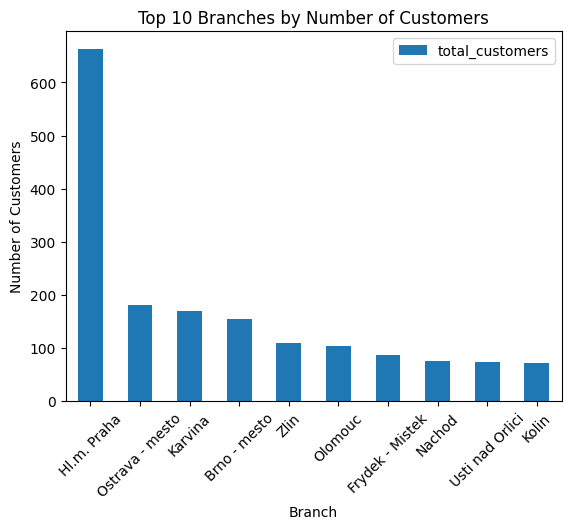

In [179]:
#Branches with the highest number of customer
branch_customers = spark.sql("""
SELECT
    d.A2 AS branch_name,
    COUNT(DISTINCT c.client_id) AS total_customers
FROM client c
JOIN district d
    ON c.district_id = d.A1
GROUP BY d.A2
ORDER BY total_customers DESC
""")

branch_customers.show()

import matplotlib.pyplot as plt

df = branch_customers.toPandas()

df.head(10).plot(kind='bar', x='branch_name', y='total_customers')

plt.title("Top 10 Branches by Number of Customers")
plt.xlabel("Branch")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

#### ii. Which branches have shown a significant decline in the monthly number of accounts opened?


+-------+----+-----+--------------+
| branch|year|month|total_accounts|
+-------+----+-----+--------------+
|Benesov|  93|   02|             2|
|Benesov|  93|   03|             1|
|Benesov|  93|   07|             2|
|Benesov|  93|   09|             2|
|Benesov|  93|   10|             1|
|Benesov|  93|   12|             1|
|Benesov|  94|   04|             1|
|Benesov|  94|   05|             1|
|Benesov|  94|   06|             3|
|Benesov|  94|   09|             1|
|Benesov|  95|   02|             1|
|Benesov|  95|   05|             1|
|Benesov|  95|   07|             1|
|Benesov|  95|   12|             1|
|Benesov|  96|   02|             2|
|Benesov|  96|   03|             1|
|Benesov|  96|   04|             1|
|Benesov|  96|   06|             3|
|Benesov|  96|   07|             3|
|Benesov|  96|   09|             2|
+-------+----+-----+--------------+
only showing top 20 rows


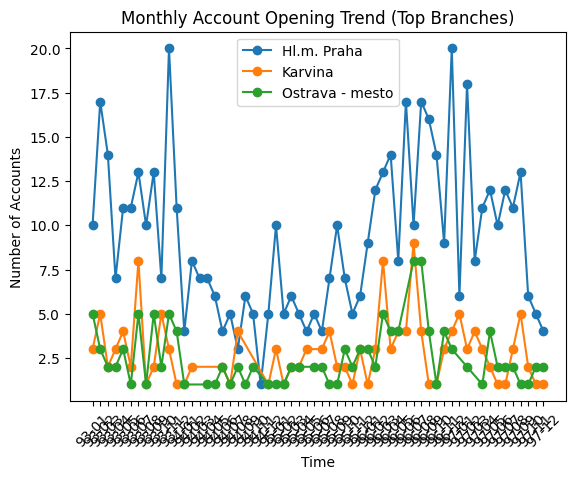

+---------------+-------------------+------------------+
|         branch|       early_period|       late_period|
+---------------+-------------------+------------------+
|        Trutnov|0.20408163265306123|0.7959183673469388|
|      Domazlice| 0.2222222222222222|0.7777777777777778|
|  Plzen - mesto|0.15555555555555556|0.8444444444444444|
|  Praha - zapad| 0.3333333333333333|0.6666666666666666|
|       Kromeriz| 0.2631578947368421|0.7368421052631579|
|         Tachov|               0.32|              0.68|
|         Semily| 0.1891891891891892|0.8108108108108109|
|     Ceska Lipa|0.22916666666666666|0.7708333333333334|
|      Pelhrimov|0.16666666666666666|0.8333333333333334|
|        Liberec|0.21052631578947367|0.7894736842105263|
| Mlada Boleslav|0.19642857142857142|0.8035714285714286|
| Hradec Kralove| 0.2653061224489796|0.7346938775510204|
|       Chomutov|0.15384615384615385|0.8461538461538461|
|Ostrava - mesto| 0.2814814814814815|0.7185185185185186|
|      Pardubice|0.320754716981

In [180]:
# Create monthly account count
monthly_accounts = spark.sql("""
SELECT
    d.A2 AS branch,
    SUBSTRING(a.date,1,2) AS year,
    SUBSTRING(a.date,3,2) AS month,
    COUNT(a.account_id) AS total_accounts
FROM account a
JOIN district d
    ON a.district_id = d.A1
GROUP BY d.A2, year, month
ORDER BY branch, year, month
""")

monthly_accounts.show()

# Convert to pandas for trend analysis
df = monthly_accounts.toPandas()
df['period'] = df['year'] + '-' + df['month']

# Plot trend for each branch
import matplotlib.pyplot as plt

top_branches = df['branch'].value_counts().head(3).index

for b in top_branches:
    temp = df[df['branch'] == b]
    plt.plot(temp['period'], temp['total_accounts'], marker='o', label=b)

plt.xticks(rotation=45)
plt.title("Monthly Account Opening Trend (Top Branches)")
plt.xlabel("Time")
plt.ylabel("Number of Accounts")
plt.legend()
plt.show()

# Identify declining branches
from pyspark.sql import functions as F

decline_check = spark.sql("""
SELECT
    d.A2 AS branch,
    AVG(CASE WHEN SUBSTRING(a.date,1,2) <= '93' THEN 1 ELSE 0 END) AS early_period,
    AVG(CASE WHEN SUBSTRING(a.date,1,2) > '93' THEN 1 ELSE 0 END) AS late_period
FROM account a
JOIN district d
    ON a.district_id = d.A1
GROUP BY d.A2
""")

decline_check.show()

# Find declining branches
decline_check.filter("late_period < early_period").show()

#### iii. How many of our clients are men/women?


Hint:
- Females have +50 added to their Month in Date of birth

In [181]:
#Gender count
gender_count = spark.sql("""
SELECT
    CASE
        WHEN CAST(SUBSTRING(birth_number, 3, 2) AS INT) > 50 THEN 'Women'
        ELSE 'Men'
    END AS gender,
    COUNT(*) AS total_clients
FROM client
GROUP BY gender
""")

gender_count.show()

+------+-------------+
|gender|total_clients|
+------+-------------+
|   Men|         2724|
| Women|         2645|
+------+-------------+



### b. Credit Cards


#### i. Which card types are popular among the various client categories (gender/age group/region)?
Hint:
- You can read the query in pandas and plot for ease

In [182]:
# Build base joined dataset
card_data = spark.sql("""
SELECT
    ca.type AS card_type,

    CASE
        WHEN CAST(SUBSTRING(c.birth_number, 3, 2) AS INT) > 50 THEN 'Female'
        ELSE 'Male'
    END AS gender,

    d.A3 AS region,
    c.birth_number

FROM card ca
JOIN relationship r ON ca.disp_id = r.disp_id
JOIN client c ON r.client_id = c.client_id
JOIN district d ON c.district_id = d.A1
""")

# Add age group
card_data = card_data.withColumn(
    "age_group",
    F.when(F.substring("birth_number", 1, 2).cast("int") < 25, "Young")
     .when(F.substring("birth_number", 1, 2).cast("int").between(25, 50), "Adult")
     .otherwise("Senior")
)

# Aggregate
card_popularity = card_data.groupBy(
    "card_type", "gender", "region", "age_group"
).count().orderBy("count", ascending=False)

card_popularity.show()

+---------+------+---------------+---------+-----+
|card_type|gender|         region|age_group|count|
+---------+------+---------------+---------+-----+
|  classic|Female|  south Moravia|   Senior|   36|
|  classic|Female|central Bohemia|   Senior|   32|
|  classic|  Male|  north Moravia|   Senior|   31|
|  classic|  Male|         Prague|   Senior|   30|
|  classic|Female|         Prague|   Senior|   29|
|  classic|  Male|   west Bohemia|   Senior|   27|
|  classic|  Male|  south Moravia|   Senior|   27|
|  classic|  Male|  north Bohemia|   Senior|   25|
|  classic|  Male|central Bohemia|    Adult|   23|
|  classic|  Male|   east Bohemia|   Senior|   22|
|  classic|Female|   west Bohemia|   Senior|   22|
|  classic|Female|  north Moravia|    Adult|   22|
|  classic|  Male|central Bohemia|   Senior|   21|
|  classic|Female|  north Moravia|   Senior|   21|
|  classic|  Male|         Prague|    Adult|   20|
|  classic|Female|  north Bohemia|   Senior|   20|
|  classic|  Male|   east Bohem

+---------+------+-------------+------------+---------+
|card_type|gender|       region|birth_number|age_group|
+---------+------+-------------+------------+---------+
|     gold|  Male|south Moravia|      351016|    Adult|
|  classic|  Male| east Bohemia|      421228|    Adult|
|     gold|  Male| west Bohemia|      680827|   Senior|
|  classic|  Male|north Moravia|      350817|    Adult|
|   junior|Female|north Bohemia|      796202|   Senior|
|  classic|  Male|south Bohemia|      600331|   Senior|
|   junior|  Male|north Moravia|      800219|   Senior|
|  classic|Female|north Bohemia|      676001|   Senior|
|  classic|Female|       Prague|      565218|   Senior|
|     gold|Female|north Bohemia|      695310|   Senior|
|   junior|Female|       Prague|      786225|   Senior|
|  classic|Female|north Moravia|      466117|    Adult|
|  classic|  Male|       Prague|      350125|    Adult|
|  classic|Female|north Moravia|      695624|   Senior|
|  classic|  Male|north Moravia|      420128|   

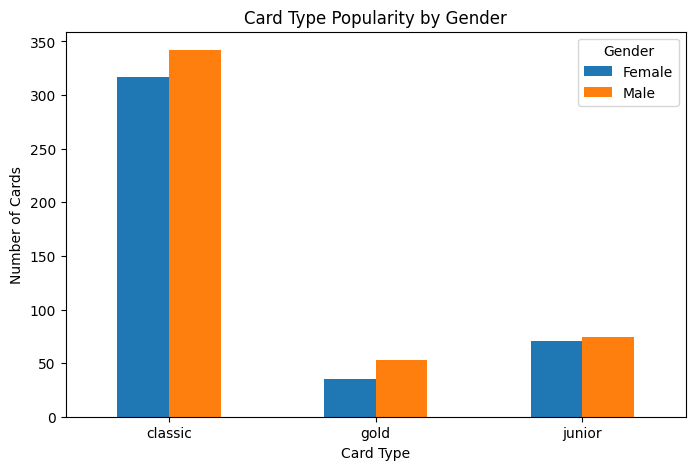

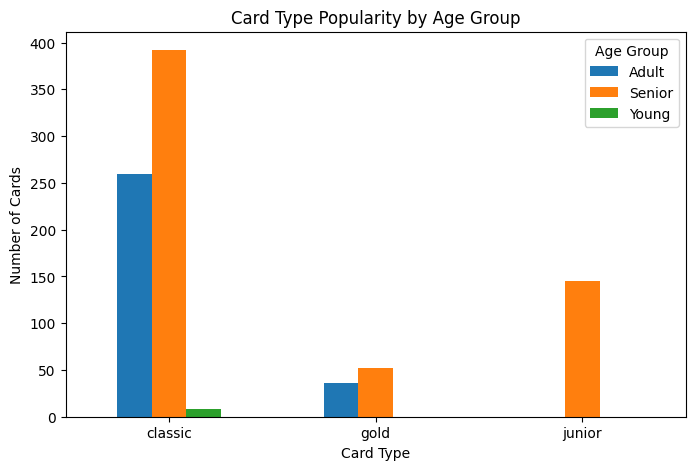

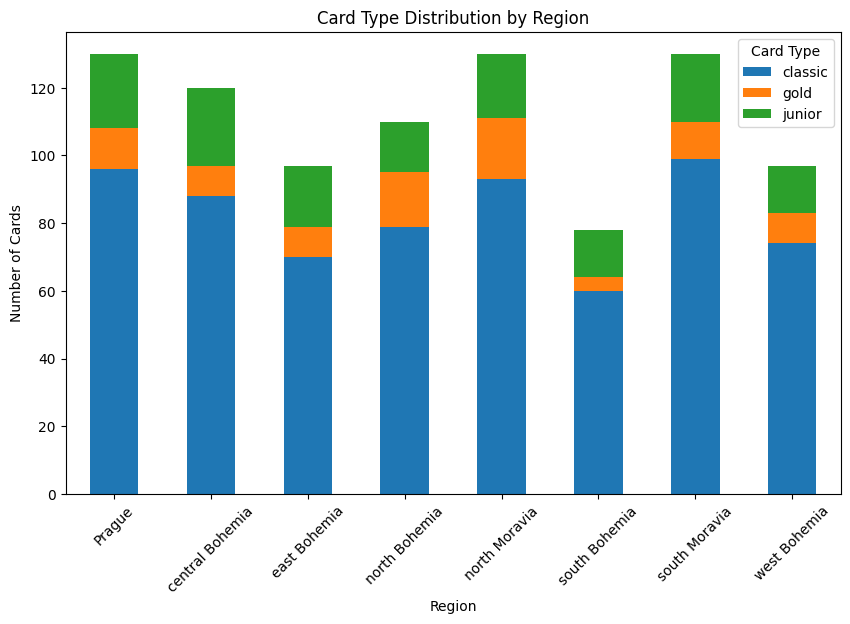

In [183]:
# check dataset
card_data.show()

# Convert to Pandas
df = card_data.groupBy(
    "card_type", "gender", "age_group", "region"
).count().toPandas()

#CHART 1 - Card Type by Gender
import matplotlib.pyplot as plt

pivot_gender = df.pivot_table(
    index="card_type",
    columns="gender",
    values="count",
    aggfunc="sum"
)

pivot_gender.plot(kind="bar", figsize=(8,5))

plt.title("Card Type Popularity by Gender")
plt.xlabel("Card Type")
plt.ylabel("Number of Cards")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.show()

# CHART 2 -Card Type by Age Group
pivot_age = df.pivot_table(
    index="card_type",
    columns="age_group",
    values="count",
    aggfunc="sum"
)

pivot_age.plot(kind="bar", figsize=(8,5))

plt.title("Card Type Popularity by Age Group")
plt.xlabel("Card Type")
plt.ylabel("Number of Cards")
plt.xticks(rotation=0)
plt.legend(title="Age Group")
plt.show()

#CHART 3 — Card Type by Region
pivot_region = df.pivot_table(
    index="region",
    columns="card_type",
    values="count",
    aggfunc="sum"
)

pivot_region.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Card Type Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Cards")
plt.xticks(rotation=45)
plt.legend(title="Card Type")
plt.show()

#### ii. What is the trend of card issuance at the various branches?

+-----------+----+-----+-----------+
|     branch|year|month|total_cards|
+-----------+----+-----+-----------+
|Hl.m. Praha|  98|   03|          6|
|     Melnik|  97|   09|          1|
|     Vsetin|  98|   02|          1|
|     Vyskov|  98|   12|          1|
|       Zlin|  98|   12|          1|
|       Zlin|  98|   05|          2|
|    Liberec|  98|   09|          1|
| Prachatice|  98|   12|          1|
|    Trutnov|  97|   11|          1|
|    Benesov|  98|   08|          1|
|  Pelhrimov|  96|   08|          1|
|    Liberec|  96|   06|          1|
|  Prostejov|  97|   08|          1|
|     Melnik|  98|   07|          1|
|    Sokolov|  98|   11|          1|
|      Opava|  98|   01|          1|
|      Kolin|  97|   07|          1|
|Hl.m. Praha|  95|   07|          1|
|    Olomouc|  94|   06|          1|
|      Pisek|  97|   09|          2|
+-----------+----+-----+-----------+
only showing top 20 rows


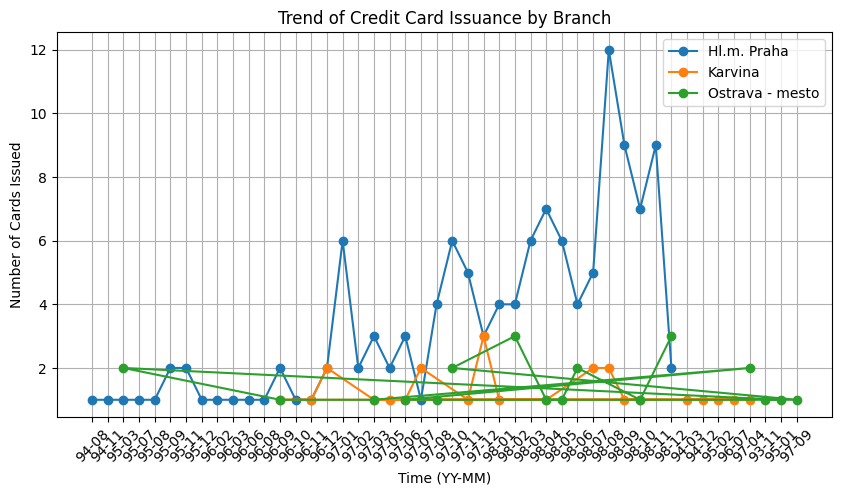

+---------------+------------+------------+
|         branch|early_period|later_period|
+---------------+------------+------------+
|        Trutnov|           1|          10|
|      Domazlice|           0|           8|
|  Plzen - mesto|           0|          10|
|  Praha - zapad|           0|           8|
|       Kromeriz|           0|           8|
|         Tachov|           0|          11|
|         Semily|           1|           4|
|     Ceska Lipa|           0|           7|
|      Pelhrimov|           0|           6|
|        Liberec|           0|          17|
| Mlada Boleslav|           0|          12|
| Hradec Kralove|           1|           5|
|       Chomutov|           0|           8|
|Ostrava - mesto|           1|          23|
|      Pardubice|           0|          17|
|Frydek - Mistek|           0|          13|
| Praha - vychod|           0|           7|
|         Kladno|           0|           9|
|         Vyskov|           0|          10|
|        Blansko|           0|  

In [184]:
# Build dataset
card_trend = spark.sql("""
SELECT
    d.A2 AS branch,
    SUBSTRING(ca.issued, 1, 2) AS year,
    SUBSTRING(ca.issued, 3, 2) AS month,
    COUNT(*) AS total_cards
FROM card ca
JOIN relationship r
    ON ca.disp_id = r.disp_id
JOIN client c
    ON r.client_id = c.client_id
JOIN district d
    ON c.district_id = d.A1
GROUP BY d.A2, year, month
""")
card_trend.show()

# Create proper time column
df = card_trend.toPandas()
df["period"] = df["year"] + "-" + df["month"]
df = df.sort_values(["period"])

# Plot trend
import matplotlib.pyplot as plt

top_branches = df.groupby("branch")["total_cards"].sum().nlargest(3).index

plt.figure(figsize=(10,5))

for branch in top_branches:
    temp = df[df["branch"] == branch]
    plt.plot(temp["period"], temp["total_cards"], marker="o", label=branch)

plt.title("Trend of Credit Card Issuance by Branch")
plt.xlabel("Time (YY-MM)")
plt.ylabel("Number of Cards Issued")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

# Branch trend
branch_trend = spark.sql("""
SELECT
    d.A2 AS branch,
    COUNT(CASE WHEN SUBSTRING(ca.issued,1,2) <= '94' THEN 1 END) AS early_period,
    COUNT(CASE WHEN SUBSTRING(ca.issued,1,2) > '94' THEN 1 END) AS later_period
FROM card ca
JOIN relationship r ON ca.disp_id = r.disp_id
JOIN client c ON r.client_id = c.client_id
JOIN district d ON c.district_id = d.A1
GROUP BY d.A2
""")

branch_trend.show()

### c. Loans


#### i. What is the distribution of loan quantum given out by the bank?

+----------+----------+----------+----------+
|min_amount|max_amount|avg_amount|std_amount|
+----------+----------+----------+----------+
|      4980|    590820| 151410.18| 113372.41|
+----------+----------+----------+----------+



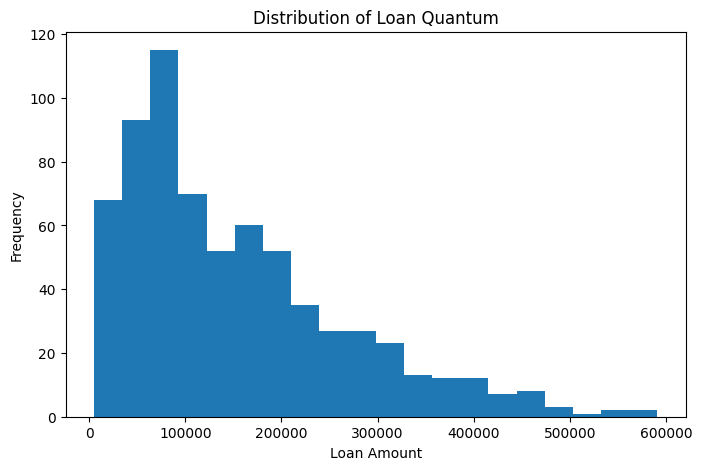

In [185]:
# Basic statistics
spark.sql("""
SELECT
    MIN(amount) AS min_amount,
    MAX(amount) AS max_amount,
    ROUND(AVG(amount),2) AS avg_amount,
    ROUND(STDDEV(amount),2) AS std_amount
FROM loan
""").show()

# Histogram
df = spark.sql("""
SELECT amount
FROM loan
""").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["amount"], bins=20)

plt.title("Distribution of Loan Quantum")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

#### ii. What is the relation between loan quantum and average salary?

+-------+-----------+--------------+
|loan_id|loan_amount|average_salary|
+-------+-----------+--------------+
|   6077|      79608|          8254|
|   7284|      52788|          9045|
|   7121|      21924|          8743|
|   5754|      23052|          9897|
|   6895|      41904|          9893|
|   6202|      65184|          9897|
|   6316|      76908|          8754|
|   5325|     105804|          8754|
|   6888|      39576|         12541|
|   6647|     208320|         12541|
|   6150|      83016|         10177|
|   6577|      51696|         10673|
|   6863|     127080|          8390|
|   5130|      24312|          8427|
|   5316|     165960|          8369|
|   7240|     274740|         12541|
|   6004|     143904|          8754|
|   4959|      80952|         12541|
|   6499|      80952|         12541|
|   5479|      24516|         12541|
+-------+-----------+--------------+
only showing top 20 rows


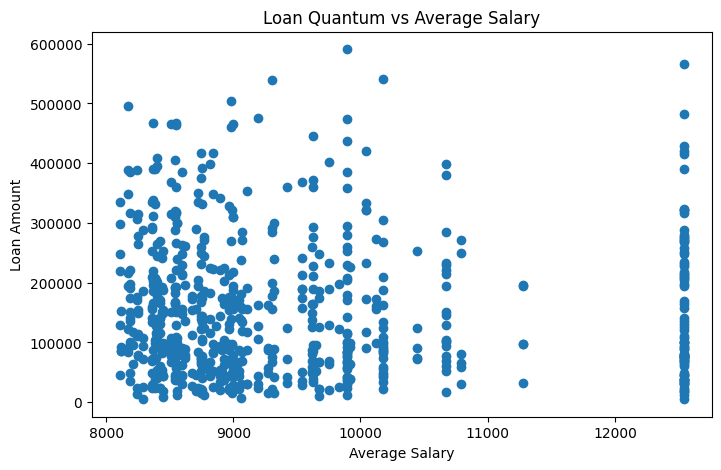

In [186]:
# Correlation between loan quantum and average salary
loan_salary = spark.sql("""
SELECT
    l.loan_id,
    l.amount AS loan_amount,
    d.A11 AS average_salary

FROM loan l

JOIN account a
    ON l.account_id = a.account_id

JOIN district d
    ON a.district_id = d.A1
""")
loan_salary.show()

# Correlation analysis
loan_salary.stat.corr("loan_amount", "average_salary")

# Scatter plot
df = loan_salary.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["average_salary"], df["loan_amount"])

plt.title("Loan Quantum vs Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("Loan Amount")

plt.show()

#### iii. Examine the relationship between the number of loans in arrears and the unemployment rate at the time.

+-----------------+-----------+-------------+------------+
|unemployment_rate|total_loans|arrears_loans|arrears_rate|
+-----------------+-----------+-------------+------------+
|             0.29|         84|            7|      0.0833|
|             0.45|         11|            1|      0.0909|
|             0.56|          5|            0|         0.0|
|             0.65|          9|            0|         0.0|
|             1.02|          1|            0|         0.0|
|              1.1|          2|            1|         0.5|
|             1.12|         11|            1|      0.0909|
|             1.25|          5|            1|         0.2|
|             1.29|         10|            0|         0.0|
|             1.39|          8|            2|        0.25|
|             1.42|          8|            1|       0.125|
|             1.51|         17|            2|      0.1176|
|              1.6|         41|            6|      0.1463|
|             1.62|          7|            0|         0.

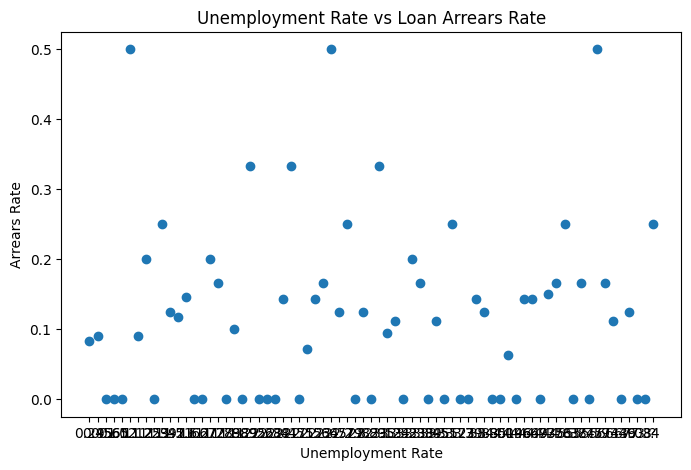

In [187]:
# Creating dataset
loan_unemp = spark.sql("""
SELECT
    l.loan_id,
    l.status,
    d.A12 AS unemployment_rate

FROM loan l

JOIN account a
    ON l.account_id = a.account_id

JOIN district d
    ON a.district_id = d.A1
""")

# rearrears indicator
loan_unemp.createOrReplaceTempView("loan_unemp_view")

loan_unemp_flag = spark.sql("""
SELECT
    unemployment_rate,
    CASE
        WHEN status IN ('B','D') THEN 1
        ELSE 0
    END AS is_arrears
FROM loan_unemp_view
""")

# aggregate relationship
loan_relationship = spark.sql("""
SELECT
    unemployment_rate,
    COUNT(*) AS total_loans,
    SUM(CASE WHEN status IN ('B','D') THEN 1 ELSE 0 END) AS arrears_loans,
    ROUND(
        SUM(CASE WHEN status IN ('B','D') THEN 1 ELSE 0 END) / COUNT(*),
        4
    ) AS arrears_rate
FROM loan_unemp_view
GROUP BY unemployment_rate
ORDER BY unemployment_rate
""")
loan_relationship.show()

# Visualisation
df = loan_relationship.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["unemployment_rate"], df["arrears_rate"])

plt.title("Unemployment Rate vs Loan Arrears Rate")
plt.xlabel("Unemployment Rate")
plt.ylabel("Arrears Rate")

plt.show()

### d. Transactions

#### i. Which region has the lowest average number of transactions?

In [188]:
# Join transactions with account + districte
txn_base = spark.sql("""
SELECT
    t.account_id,
    t.type AS transaction_type,
    t.amount,
    d.A3 AS region
FROM trans t
JOIN account a
    ON t.account_id = a.account_id
JOIN district d
    ON a.district_id = d.A1
""")

# Region-level aggregation
txn_base.createOrReplaceTempView("txn_base")
region_txn = spark.sql("""
SELECT
    region,
    COUNT(*) AS total_transactions,
    COUNT(DISTINCT account_id) AS total_accounts,
    ROUND((COUNT(*) / COUNT(DISTINCT account_id)), 2) AS avg_transactions_per_account
FROM txn_base
GROUP BY region
ORDER BY avg_transactions_per_account ASC
""")

region_txn.show()
region_txn.createOrReplaceTempView("region_txn")
print("The region with the lowest average number of transactions is:", region_txn.first()["region"])

+---------------+------------------+--------------+----------------------------+
|         region|total_transactions|total_accounts|avg_transactions_per_account|
+---------------+------------------+--------------+----------------------------+
|   east Bohemia|            121735|           544|                      223.78|
|  south Bohemia|             85542|           370|                      231.19|
|  south Moravia|            181751|           778|                      233.61|
|central Bohemia|            134543|           574|                       234.4|
|  north Bohemia|            107171|           457|                      234.51|
|   west Bohemia|            101332|           430|                      235.66|
|         Prague|            132613|           554|                      239.37|
|  north Moravia|            191633|           793|                      241.66|
+---------------+------------------+--------------+----------------------------+

The region with the lowest 

#### ii. What is the breakdown of the various transaction types?

+----------------+------------------+--------------------+
|transaction_type|total_transactions|        total_volume|
+----------------+------------------+--------------------+
|           VYDAJ|            634571| 2.821717377798581E9|
|          PRIJEM|            405083|3.2274724245000086E9|
|           VYBER|             16666|        2.08603758E8|
+----------------+------------------+--------------------+



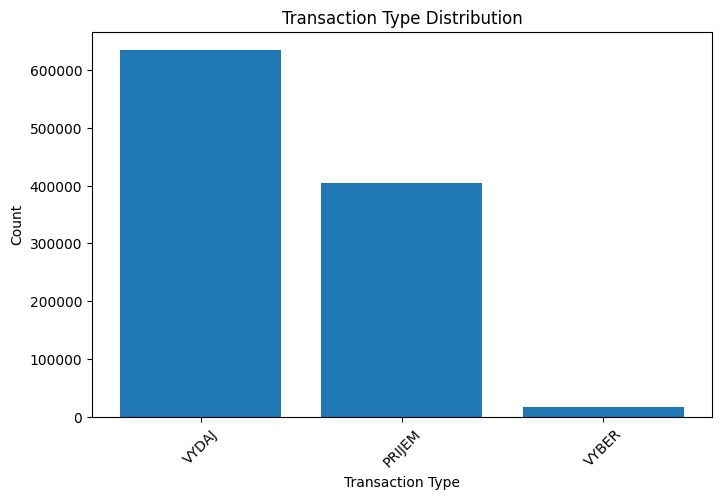

In [189]:
# Distribution
txn_type = spark.sql("""
SELECT
    transaction_type,
    COUNT(*) AS total_transactions,
    SUM(amount) AS total_volume
FROM txn_base
GROUP BY transaction_type
ORDER BY total_transactions DESC
""")

txn_type.show()

# Visualisation
df = txn_type.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["transaction_type"], df["total_transactions"])
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 3- Merge the Data for loan default model, keeping in mind that all observations in the loan table are important as these are the people who applied for loans

In [190]:
df_trans.show()

+--------+----------+------+------+-------------+------+-------+--------+----+--------+
|trans_id|account_id|  date|  type|    operation|amount|balance|k_symbol|bank| account|
+--------+----------+------+------+-------------+------+-------+--------+----+--------+
|  695247|      2378|930101|PRIJEM|        VKLAD| 700.0|  700.0|    NULL|NULL|    NULL|
|  171812|       576|930101|PRIJEM|        VKLAD| 900.0|  900.0|    NULL|NULL|    NULL|
|  207264|       704|930101|PRIJEM|        VKLAD|1000.0| 1000.0|    NULL|NULL|    NULL|
| 1117247|      3818|930101|PRIJEM|        VKLAD| 600.0|  600.0|    NULL|NULL|    NULL|
|  579373|      1972|930102|PRIJEM|        VKLAD| 400.0|  400.0|    NULL|NULL|    NULL|
|  771035|      2632|930102|PRIJEM|        VKLAD|1100.0| 1100.0|    NULL|NULL|    NULL|
|  452728|      1539|930103|PRIJEM|        VKLAD| 600.0|  600.0|    NULL|NULL|    NULL|
|  725751|      2484|930103|PRIJEM|        VKLAD|1100.0| 1100.0|    NULL|NULL|    NULL|
|  497211|      1695|930103|PRIJ

In [191]:
loan_default_model = spark.sql("""

-- Step 1: Loan table
WITH loan_base AS (

    SELECT *
    FROM loan

),

-- Step 2: Join loan with account
loan_account AS (

    SELECT
        l.loan_id,
        l.account_id,
        l.amount,
        l.duration,
        l.payments,
        l.status,

        a.district_id,
        a.frequency,
        a.date AS account_date

    FROM loan_base l

    LEFT JOIN account a
        ON l.account_id = a.account_id

),

-- Step 3: Add district information
loan_district AS (

    SELECT
        la.*,

        d.A2 AS district_name,
        d.A3 AS region,
        d.A11 AS average_salary,
        d.A13 AS unemployment_rate,
        d.A15 AS crime_1995,
        d.A16 AS crime_1996

    FROM loan_account la

    LEFT JOIN district d
        ON la.district_id = d.A1

),

-- Step 4: Add client information
loan_client AS (

    SELECT
        ld.*,

        c.birth_number,

        CASE
            WHEN CAST(SUBSTRING(c.birth_number, 3, 2) AS INT) > 50
                THEN 1
            ELSE 0
        END AS gender

    FROM loan_district ld

    LEFT JOIN relationship r
        ON ld.account_id = r.account_id
        AND r.type = 'OWNER'

    LEFT JOIN client c
        ON r.client_id = c.client_id

),

-- Step 5: Create transaction features
txn_features AS (

    SELECT
        t.account_id,

        COUNT(*) AS total_transactions,
        SUM(t.amount) AS total_txn_amount,
        AVG(t.amount) AS avg_txn_amount,

        MAX(t.type) AS transaction_type,
        MAX(t.operation) AS transaction_operation

    FROM trans t

    GROUP BY t.account_id

)

-- Final dataset
SELECT
    lc.*,

    tf.total_transactions,
    tf.total_txn_amount,
    tf.avg_txn_amount,
    tf.transaction_type,
    tf.transaction_operation

FROM loan_client lc

LEFT JOIN txn_features tf
    ON lc.account_id = tf.account_id

""")

loan_default_model.show()

+-------+----------+------+--------+--------+------+-----------+------------------+------------+----------------+---------------+--------------+-----------------+----------+----------+------------+------+------------------+------------------+------------------+----------------+---------------------+
|loan_id|account_id|amount|duration|payments|status|district_id|         frequency|account_date|   district_name|         region|average_salary|unemployment_rate|crime_1995|crime_1996|birth_number|gender|total_transactions|  total_txn_amount|    avg_txn_amount|transaction_type|transaction_operation|
+-------+----------+------+--------+--------+------+-----------+------------------+------------+----------------+---------------+--------------+-----------------+----------+----------+------------+------+------------------+------------------+------------------+----------------+---------------------+
|   5314|      1787| 96396|      12|  8033.0|     B|         30|    POPLATEK TYDNE|      930322| 

## 4- Preprocess the data and handle any missing values after merging

In [192]:
# Check for missing values
from pyspark.sql.functions import col, sum

print("Missing values:")
loan_default_model.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in loan_default_model.columns
]).show()

# Duplicates check
print(f"No. of duplicates: {loan_default_model.count() - loan_default_model.dropDuplicates().count()}")

Missing values:
+-------+----------+------+--------+--------+------+-----------+---------+------------+-------------+------+--------------+-----------------+----------+----------+------------+------+------------------+----------------+--------------+----------------+---------------------+
|loan_id|account_id|amount|duration|payments|status|district_id|frequency|account_date|district_name|region|average_salary|unemployment_rate|crime_1995|crime_1996|birth_number|gender|total_transactions|total_txn_amount|avg_txn_amount|transaction_type|transaction_operation|
+-------+----------+------+--------+--------+------+-----------+---------+------------+-------------+------+--------------+-----------------+----------+----------+------------+------+------------------+----------------+--------------+----------------+---------------------+
|      0|         0|     0|       0|       0|     0|          0|        0|           0|            0|     0|             0|                0|         0|         0

In [193]:
# Check grain correctness
loan_default_model.groupBy("loan_id").count().orderBy("count", ascending=False).show(10)

# Keep only 1 row per loan_id
loan_clean = loan_default_model.dropDuplicates(["loan_id"])

print("Total rows:", loan_clean.count())

print("Unique loan_id rows:", loan_clean.select("loan_id").distinct().count())

print("Remaining duplicates:",
      loan_clean.count() - loan_clean.select("loan_id").distinct().count())

loan_clean.show()


+-------+-----+
|loan_id|count|
+-------+-----+
|   7240|    1|
|   6336|    1|
|   7253|    1|
|   6357|    1|
|   7168|    1|
|   5614|    1|
|   5117|    1|
|   5287|    1|
|   7066|    1|
|   6598|    1|
+-------+-----+
only showing top 10 rows
Total rows: 682
Unique loan_id rows: 682
Remaining duplicates: 0
+-------+----------+------+--------+--------+------+-----------+------------------+------------+-----------------+-------------+--------------+-----------------+----------+----------+------------+------+------------------+------------------+------------------+----------------+---------------------+
|loan_id|account_id|amount|duration|payments|status|district_id|         frequency|account_date|    district_name|       region|average_salary|unemployment_rate|crime_1995|crime_1996|birth_number|gender|total_transactions|  total_txn_amount|    avg_txn_amount|transaction_type|transaction_operation|
+-------+----------+------+--------+--------+------+-----------+------------------+---

## 5- Check for the outliers and anomalies

In [194]:
# Amount outliers
loan_clean.createOrReplaceTempView("loan_clean")
amount_outliers = spark.sql("""
WITH quartiles AS (
    SELECT
        percentile_approx(amount, 0.25) AS Q1,
        percentile_approx(amount, 0.75) AS Q3
    FROM loan_clean
),

bounds AS (
    SELECT
        Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
        Q3 + 1.5 * (Q3 - Q1) AS upper_bound
    FROM quartiles
)

SELECT
    COUNT(*) AS total_amount_outliers
FROM loan_clean l
CROSS JOIN bounds b
WHERE l.amount < b.lower_bound
   OR l.amount > b.upper_bound
""")

amount_outliers.show()

#Checking for payment outliers

payment_outliers = spark.sql("""
WITH quartiles AS (
    SELECT
        percentile_approx(payments, 0.25) AS Q1,
        percentile_approx(payments, 0.75) AS Q3
    FROM loan_clean
),

bounds AS (
    SELECT
        Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
        Q3 + 1.5 * (Q3 - Q1) AS upper_bound
    FROM quartiles
)

SELECT
    COUNT(*) AS total_payments_outliers
FROM loan_clean l
CROSS JOIN bounds b
WHERE l.payments < b.lower_bound
   OR l.payments > b.upper_bound
""")

payment_outliers.show()


#Checking for duration outliers
duration_outliers = spark.sql("""
WITH quartiles AS (
    SELECT
        percentile_approx(duration, 0.25) AS Q1,
        percentile_approx(duration, 0.75) AS Q3
    FROM loan_clean
),

bounds AS (
    SELECT
        Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
        Q3 + 1.5 * (Q3 - Q1) AS upper_bound
    FROM quartiles
)

SELECT
    COUNT(*) AS total_duration_outliers
FROM loan_clean l
CROSS JOIN bounds b
WHERE l.duration < b.lower_bound
   OR l.duration > b.upper_bound
""")

duration_outliers.show()


#Checking for average_salary outliers
avg_salary_outliers = spark.sql("""
WITH quartiles AS (
    SELECT
        percentile_approx(average_salary, 0.25) AS Q1,
        percentile_approx(average_salary, 0.75) AS Q3
    FROM loan_clean
),

bounds AS (
    SELECT
        Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
        Q3 + 1.5 * (Q3 - Q1) AS upper_bound
    FROM quartiles
)

SELECT
    COUNT(*) AS total_salary_outliers
FROM loan_clean l
CROSS JOIN bounds b
WHERE l.average_salary < b.lower_bound
   OR l.average_salary > b.upper_bound
""")

avg_salary_outliers.show()

#Checking for unemployment rate outliers
unemployment_rate_outliers = spark.sql("""
WITH quartiles AS (
    SELECT
        percentile_approx(unemployment_rate, 0.25) AS Q1,
        percentile_approx(unemployment_rate, 0.75) AS Q3
    FROM loan_clean
),

bounds AS (
    SELECT
        Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
        Q3 + 1.5 * (Q3 - Q1) AS upper_bound
    FROM quartiles
)

SELECT
    COUNT(*) AS total_unemployment_outliers
FROM loan_clean l
CROSS JOIN bounds b
WHERE l.unemployment_rate < b.lower_bound
   OR l.unemployment_rate > b.upper_bound
""")

unemployment_rate_outliers.show()

#Checking for crime_1995 outliers
crime_1995_outliers = spark.sql("""
WITH cleaned AS (
    SELECT
        TRY_CAST(crime_1995 AS DOUBLE) AS crime_1995
    FROM loan_clean
),

quartiles AS (
    SELECT
        percentile_approx(crime_1995, 0.25) AS Q1,
        percentile_approx(crime_1995, 0.75) AS Q3
    FROM cleaned
    WHERE crime_1995 IS NOT NULL
),

bounds AS (
    SELECT
        Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
        Q3 + 1.5 * (Q3 - Q1) AS upper_bound
    FROM quartiles
)

SELECT
    COUNT(*) AS crime_1995_outliers
FROM cleaned l
CROSS JOIN bounds b
WHERE l.crime_1995 < b.lower_bound
   OR l.crime_1995 > b.upper_bound
""")
crime_1995_outliers.show()

# crime_1996 outliers
crime_1996_outliers = spark.sql("""
WITH quartiles AS (
    SELECT
        percentile_approx(crime_1996, 0.25) AS Q1,
        percentile_approx(crime_1996, 0.75) AS Q3
    FROM loan_clean
),

bounds AS (
    SELECT
        Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
        Q3 + 1.5 * (Q3 - Q1) AS upper_bound
    FROM quartiles
)

SELECT
    COUNT(*) AS crime_1996_outliers
FROM loan_clean l
CROSS JOIN bounds b
WHERE l.crime_1996 < b.lower_bound
   OR l.crime_1996 > b.upper_bound
   """)
crime_1996_outliers.show()

# Total transaction outliers
total_txn_outliers = spark.sql("""
    WITH quartiles AS (
    SELECT
        percentile_approx(total_transactions, 0.25) AS Q1,
        percentile_approx(total_transactions, 0.75) AS Q3
    FROM loan_clean
),

bounds AS (
    SELECT
        Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
        Q3 + 1.5 * (Q3 - Q1) AS upper_bound
    FROM quartiles
)

SELECT
    COUNT(*) AS total_transactions_outliers
FROM loan_clean l
CROSS JOIN bounds b
WHERE l.total_transactions < b.lower_bound
   OR l.total_transactions > b.upper_bound
   """)
total_txn_outliers.show()

# Total transaction amount outliers
total_txn_amount_outliers = spark.sql("""
    WITH quartiles AS (
    SELECT
        percentile_approx(total_txn_amount, 0.25) AS Q1,
        percentile_approx(total_txn_amount, 0.75) AS Q3
    FROM loan_clean
    ),

    bounds AS (
        SELECT
            Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
            Q3 + 1.5 * (Q3 - Q1) AS upper_bound
        FROM quartiles
    )

    SELECT
        COUNT(*) AS total_txn_amount_outliers
    FROM loan_clean l
    CROSS JOIN bounds b
    WHERE l.total_txn_amount < b.lower_bound
      OR l.total_txn_amount > b.upper_bound
      """)
total_txn_amount_outliers.show()

# Average transaction amount outliers
avg_txn_amount_outliers = spark.sql("""
WITH quartiles AS (
    SELECT
        percentile_approx(avg_txn_amount, 0.25) AS Q1,
        percentile_approx(avg_txn_amount, 0.75) AS Q3
    FROM loan_clean
),

bounds AS (
    SELECT
        Q1 - 1.5 * (Q3 - Q1) AS lower_bound,
        Q3 + 1.5 * (Q3 - Q1) AS upper_bound
    FROM quartiles
)

SELECT
    COUNT(*) AS avg_txn_amount_outliers
FROM loan_clean l
CROSS JOIN bounds b
WHERE l.avg_txn_amount < b.lower_bound
   OR l.avg_txn_amount > b.upper_bound
""")
avg_txn_amount_outliers.show()

+---------------------+
|total_amount_outliers|
+---------------------+
|                   18|
+---------------------+

+-----------------------+
|total_payments_outliers|
+-----------------------+
|                      0|
+-----------------------+

+-----------------------+
|total_duration_outliers|
+-----------------------+
|                      0|
+-----------------------+

+---------------------+
|total_salary_outliers|
+---------------------+
|                   84|
+---------------------+

+---------------------------+
|total_unemployment_outliers|
+---------------------------+
|                          5|
+---------------------------+

+-------------------+
|crime_1995_outliers|
+-------------------+
|                128|
+-------------------+

+-------------------+
|crime_1996_outliers|
+-------------------+
|                128|
+-------------------+

+---------------------------+
|total_transactions_outliers|
+---------------------------+
|                          0|
+--

In [195]:
# anomalies

# missing values
print('missing values:')
from pyspark.sql.functions import col, count, when

loan_clean.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in loan_clean.columns
]).show()

# invalid values
print('invalid values of ?')
spark.sql("""SELECT *
FROM loan_clean
WHERE crime_1995 = '?'""").show()

# negative values
print('negative values:')
spark.sql("""
SELECT *
FROM loan_clean
WHERE amount < 0
   OR payments < 0
   OR total_txn_amount < 0
   """).show()

# Zero values
print('zero values:')
spark.sql("""
SELECT *
FROM loan_clean
WHERE amount = 0
   OR payments = 0
   OR total_txn_amount = 0
   """).show()

# duplicate loan_id
print('duplicate loan_id:')
spark.sql("""
SELECT loan_id, COUNT(*) AS total
FROM loan_clean
GROUP BY loan_id
HAVING COUNT(*) > 1
""").show()

# Invalid categories
print('invalid categories:')
spark.sql("""SELECT DISTINCT status
FROM loan_clean""").show()

# Logical anomalies
print('Logical anomalies:')
spark.sql("""
SELECT *
FROM loan_clean
WHERE payments > amount
""").show()

missing values:
+-------+----------+------+--------+--------+------+-----------+---------+------------+-------------+------+--------------+-----------------+----------+----------+------------+------+------------------+----------------+--------------+----------------+---------------------+
|loan_id|account_id|amount|duration|payments|status|district_id|frequency|account_date|district_name|region|average_salary|unemployment_rate|crime_1995|crime_1996|birth_number|gender|total_transactions|total_txn_amount|avg_txn_amount|transaction_type|transaction_operation|
+-------+----------+------+--------+--------+------+-----------+---------+------------+-------------+------+--------------+-----------------+----------+----------+------------+------+------------------+----------------+--------------+----------------+---------------------+
|      0|         0|     0|       0|       0|     0|          0|        0|           0|            0|     0|             0|                0|         0|         0

## 6- Check the variables A15 and A16 in the district table, do you see any unsual thing?

In [196]:
variables_A15_A16 = spark.sql("""
WITH cleaned AS (
    SELECT
        A1,
        A2 AS district_name,

        TRY_CAST(A15 AS DOUBLE) AS A15,
        TRY_CAST(A16 AS DOUBLE) AS A16

    FROM district
),

calculated AS (
    SELECT
        A1,
        district_name,
        A15,
        A16,

        (A16 - A15) AS absolute_change,

        ROUND(
            (A16 - A15) / A15 * 100, 2
        ) AS pct_change

    FROM cleaned
    WHERE A15 IS NOT NULL AND A16 IS NOT NULL
)

SELECT
    *,
    CASE
        WHEN ABS(absolute_change) > 20000 THEN 'ANOMALY (Very High Gap)'
        WHEN A15 > 50000 OR A16 > 50000 THEN 'HIGH CRIME REGION (Prague effect)'
        ELSE 'NORMAL'
    END AS status

FROM calculated

ORDER BY ABS(absolute_change) DESC
""")

variables_A15_A16.show(20, False)

+---+---------------+-------+-------+---------------+----------+---------------------------------+
|A1 |district_name  |A15    |A16    |absolute_change|pct_change|status                           |
+---+---------------+-------+-------+---------------+----------+---------------------------------+
|1  |Hl.m. Praha    |85677.0|99107.0|13430.0        |15.68     |HIGH CRIME REGION (Prague effect)|
|41 |Usti nad Labem |6445.0 |5471.0 |-974.0         |-15.11    |NORMAL                           |
|76 |Sumperk        |3736.0 |2807.0 |-929.0         |-24.87    |NORMAL                           |
|47 |Pardubice      |6079.0 |5410.0 |-669.0         |-11.01    |NORMAL                           |
|4  |Kladno         |5244.0 |5892.0 |648.0          |12.36     |NORMAL                           |
|65 |Znojmo         |2157.0 |2718.0 |561.0          |26.01     |NORMAL                           |
|7  |Melnik         |4289.0 |4846.0 |557.0          |12.99     |NORMAL                           |
|2  |Benes

In [197]:
loan_clean.show()

+-------+----------+------+--------+--------+------+-----------+------------------+------------+-----------------+-------------+--------------+-----------------+----------+----------+------------+------+------------------+------------------+------------------+----------------+---------------------+
|loan_id|account_id|amount|duration|payments|status|district_id|         frequency|account_date|    district_name|       region|average_salary|unemployment_rate|crime_1995|crime_1996|birth_number|gender|total_transactions|  total_txn_amount|    avg_txn_amount|transaction_type|transaction_operation|
+-------+----------+------+--------+--------+------+-----------+------------------+------------+-----------------+-------------+--------------+-----------------+----------+----------+------------+------+------------------+------------------+------------------+----------------+---------------------+
|   4959|         2| 80952|      24|  3373.0|     A|          1|  POPLATEK MESICNE|      930226|    

## 7- Convert all polish column names to english according to the data dictionary. For example, change 'POPLATEK MESICNE' to 'MONTHLY'.
Hint:
- Use SQL CASE statement in Pandas SQL

In [198]:
#Converting all polish column to english.
df_convert_loan_clean = spark.sql("""

SELECT
    loan_id,
    account_id,
    amount,
    duration,
    payments,
    status,
    district_id,

    CASE
        WHEN frequency = 'POPLATEK MESICNE'
            THEN 'MONTHLY'
        WHEN frequency = 'POPLATEK TYDNE'
            THEN 'WEEKLY'
        WHEN frequency = 'POPLATEK PO OBRATU'
            THEN 'TRANSACTIONAL'
        ELSE frequency
    END AS frequency,

    account_date,
    district_name,
    region,
    average_salary,
    unemployment_rate,
    crime_1995,
    crime_1996,
    gender,

    total_transactions,
    total_txn_amount,
    avg_txn_amount,

    CASE
        WHEN transaction_type = 'PRIJEM'
            THEN 'CREDIT'
        WHEN transaction_type = 'VYDAJ'
            THEN 'DEBIT'
        WHEN transaction_type = 'VYBER'
            THEN 'WITHDRAWAL'
        ELSE transaction_type
    END AS transaction_type,

    CASE
        WHEN transaction_operation = 'VYBER'
            THEN 'CASH_WITHDRAWAL'
        WHEN transaction_operation = 'VYBER KARTOU'
            THEN 'CARD_WITHDRAWAL'
        WHEN transaction_operation = 'PREVOD NA UCET'
            THEN 'TRANSFER_TO_ACCOUNT'
        WHEN transaction_operation = 'PREVOD Z UCTU'
            THEN 'TRANSFER_FROM_ACCOUNT'
        ELSE transaction_operation
    END AS transaction_operation

FROM loan_clean

""")

df_convert_loan_clean.show()

+-------+----------+------+--------+--------+------+-----------+-------------+------------+-----------------+-------------+--------------+-----------------+----------+----------+------+------------------+------------------+------------------+----------------+---------------------+
|loan_id|account_id|amount|duration|payments|status|district_id|    frequency|account_date|    district_name|       region|average_salary|unemployment_rate|crime_1995|crime_1996|gender|total_transactions|  total_txn_amount|    avg_txn_amount|transaction_type|transaction_operation|
+-------+----------+------+--------+--------+------+-----------+-------------+------------+-----------------+-------------+--------------+-----------------+----------+----------+------+------------------+------------------+------------------+----------------+---------------------+
|   4959|         2| 80952|      24|  3373.0|     A|          1|      MONTHLY|      930226|      Hl.m. Praha|       Prague|         12541|             0.4

## 8- Handle Transaction Table as a single user may have multiple transactions, Try to create high level feature.

In [199]:
# Transaction feature
txn_features = spark.sql("""

SELECT

    account_id,

    -- Transaction volume
    COUNT(*) AS total_transactions,

    -- Transaction amount statistics
    SUM(amount) AS total_txn_amount,
    AVG(amount) AS avg_txn_amount,
    MAX(amount) AS max_txn_amount,
    MIN(amount) AS min_txn_amount,

    -- Balance statistics
    AVG(balance) AS avg_balance,
    MAX(balance) AS max_balance,
    MIN(balance) AS min_balance,

    -- Transaction type counts
    SUM(CASE WHEN type = 'PRIJEM' THEN 1 ELSE 0 END)
        AS total_credit_txn,

    SUM(CASE WHEN type = 'VYDAJ' THEN 1 ELSE 0 END)
        AS total_debit_txn,

    -- Operation counts
    SUM(CASE WHEN operation = 'VYBER'
        THEN 1 ELSE 0 END)
        AS cash_withdrawal_count,

    SUM(CASE WHEN operation = 'VYBER KARTOU'
        THEN 1 ELSE 0 END)
        AS card_withdrawal_count,

    SUM(CASE WHEN operation = 'PREVOD NA UCET'
        THEN 1 ELSE 0 END)
        AS transfer_to_account_count,

    SUM(CASE WHEN operation = 'PREVOD Z UCTU'
        THEN 1 ELSE 0 END)
        AS transfer_from_account_count

FROM trans

GROUP BY account_id

""")

txn_features.show()

+----------+------------------+------------------+------------------+--------------+--------------+------------------+-----------+-----------+----------------+---------------+---------------------+---------------------+-------------------------+---------------------------+
|account_id|total_transactions|  total_txn_amount|    avg_txn_amount|max_txn_amount|min_txn_amount|       avg_balance|max_balance|min_balance|total_credit_txn|total_debit_txn|cash_withdrawal_count|card_withdrawal_count|transfer_to_account_count|transfer_from_account_count|
+----------+------------------+------------------+------------------+--------------+--------------+------------------+-----------+-----------+----------------+---------------+---------------------+---------------------+-------------------------+---------------------------+
|      2122|               470| 5550771.800000005|11810.152765957459|       63500.0|          14.6| 60335.07340425527|   176243.2|      300.0|             191|            253|   

## 9- Do you really need four categories in your Target Variable, convert it into a binary variable.
#### Use meaningful values for this variable like Defaulter and Non-defaulter.

In [200]:
#creating dataset
df_convert_loan_clean.createOrReplaceTempView("convert_loan_clean")

loan_binary = spark.sql("""
SELECT
    *,
    CASE
        WHEN status IN ('A','C') THEN 'Non-defaulter'
        WHEN status IN ('B','D') THEN 'Defaulter'
    END AS target_variable
FROM convert_loan_clean
""")

loan_binary.createOrReplaceTempView("loan_binary_view")

# Check class balance
spark.sql("""
SELECT
    target_variable,
    COUNT(*) AS total_loans
FROM loan_binary_view
GROUP BY target_variable
""").show()

+---------------+-----------+
|target_variable|total_loans|
+---------------+-----------+
|      Defaulter|         76|
|  Non-defaulter|        606|
+---------------+-----------+



## 10- Handle Class imbalance problem try using under-sampling, over-sampling, and smote

In [201]:
# Creating working dataset
loan_model = spark.sql("""
SELECT *
FROM loan_binary_view
""")

loan_model.createOrReplaceTempView("loan_model_view")

In [202]:
# Under-sampling
undersampled = spark.sql("""
WITH defaulter AS (
    SELECT * FROM loan_model_view
    WHERE target_variable = 'Defaulter'
),

non_defaulter AS (
    SELECT * FROM loan_model_view
    WHERE target_variable = 'Non-defaulter'
    ORDER BY rand()
    LIMIT 76
)

SELECT * FROM defaulter
UNION ALL
SELECT * FROM non_defaulter
""")
undersampled.groupBy("target_variable").count().show()

+---------------+-----+
|target_variable|count|
+---------------+-----+
|      Defaulter|   76|
|  Non-defaulter|   76|
+---------------+-----+



In [203]:
# Over-sampling
oversampled = spark.sql("""
WITH defaulter AS (
    SELECT * FROM loan_model_view
    WHERE target_variable = 'Defaulter'
),

non_defaulter AS (
    SELECT * FROM loan_model_view
    WHERE target_variable = 'Non-defaulter'
),

defaulter_upsampled AS (
    SELECT * FROM defaulter
    UNION ALL
    SELECT * FROM defaulter
    UNION ALL
    SELECT * FROM defaulter
    UNION ALL
    SELECT * FROM defaulter
    UNION ALL
    SELECT * FROM defaulter
)

SELECT * FROM defaulter_upsampled
UNION ALL
SELECT * FROM non_defaulter
""")
oversampled.groupBy("target_variable").count().show()

+---------------+-----+
|target_variable|count|
+---------------+-----+
|      Defaulter|  380|
|  Non-defaulter|  606|
+---------------+-----+



In [204]:
# SMOTE
import pandas as pd
df = loan_model.toPandas()

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Encode target
le = LabelEncoder()
df["target_encoded"] = le.fit_transform(df["target_variable"])

# Features (example: you can add more later)
X = df[["amount"]]
y = df["target_encoded"]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts())
print("After SMOTE:", pd.Series(y_res).value_counts())

Before SMOTE: target_encoded
1    606
0     76
Name: count, dtype: int64
After SMOTE: target_encoded
1    606
0    606
Name: count, dtype: int64


## 11- Load data into Apache Spark

In [205]:
import pyspark
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StringIndexer
from pyspark.sql import SparkSession

In [206]:
from pyspark.sql import SparkSession

In [207]:
spark = SparkSession.builder.getOrCreate()

In [208]:
import os
MAIN_DIRECTORY = os.getcwd()

In [209]:
# Assuming X_res and y_res from SMOTE in pandas
import pandas as pd

# Combine features and target into one Pandas DataFrame
smote_df_pandas = pd.concat([X_res, y_res], axis=1)

# Convert Pandas DataFrame back to Spark DataFrame
smote_df_spark = spark.createDataFrame(smote_df_pandas)

# Verify the data
print(f"Balanced Spark DataFrame Count: {smote_df_spark.count()}")
smote_df_spark.show(5)

Balanced Spark DataFrame Count: 1212
+------+--------------+
|amount|target_encoded|
+------+--------------+
| 80952|             1|
| 30276|             0|
| 30276|             1|
|318480|             0|
|110736|             1|
+------+--------------+
only showing top 5 rows


## 12- Perform preprocessing on the data set (if need be) and split the data into train and test sets.

In [210]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col

# 1. Define feature columns (everything except the target column)
# Replace 'target_encoded' with the actual name of your label column if it differs
target_col = "target_encoded"
feature_cols = [c for c in smote_df_spark.columns if c != target_col]

# 2. VectorAssembler combines multiple columns into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Transform data and rename target to 'label' for Spark ML
final_data = assembler.transform(smote_df_spark).select(
    col("features"),
    col(target_col).alias("label")
)

# 3. Train/Test Split (80% Train, 20% Test)
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

print(f"Training Data Count: {train_data.count()}")
print(f"Testing Data Count: {test_data.count()}")

Training Data Count: 983
Testing Data Count: 229


## 13- Create three machine learning algorithms using apache spark and compare these models for all three class balancing techniques, smote, over-sampling, under-sampling.

### Also, check and compare the models, which models have better performance?

In [211]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Initialize the evaluator for Binary Classification
evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

print("--- Model Performance on SMOTE Balanced Data ---")

# 1. Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
lr_auc = evaluator.evaluate(lr_predictions)
print(f"1. Logistic Regression AUC:     {lr_auc:.4f}")

# 2. Random Forest Classifier
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
rf_auc = evaluator.evaluate(rf_predictions)
print(f"2. Random Forest AUC:           {rf_auc:.4f}")

# 3. Gradient Boosted Trees (GBT)
gbt = GBTClassifier(featuresCol="features", labelCol="label", seed=42)
gbt_model = gbt.fit(train_data)
gbt_predictions = gbt_model.transform(test_data)
gbt_auc = evaluator.evaluate(gbt_predictions)
print(f"3. Gradient Boosted Trees AUC:  {gbt_auc:.4f}")

--- Model Performance on SMOTE Balanced Data ---
1. Logistic Regression AUC:     0.6442
2. Random Forest AUC:           0.6974
3. Gradient Boosted Trees AUC:  0.7056


## 14- Check whether standardization or normalization of the data has any effect on the models performance

In [212]:
from pyspark.ml.feature import StandardScaler

# 1. Initialize StandardScaler (This fixes your previous NameError)
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)

# 2. Fit the scaler on training data ONLY, then transform both train and test
scaler_model = scaler.fit(train_data)
train_scaled = scaler_model.transform(train_data)
test_scaled = scaler_model.transform(test_data)

print("--- Impact of Standardization ---")

# 3. Re-train Logistic Regression on Scaled Features
lr_scaled = LogisticRegression(featuresCol="scaledFeatures", labelCol="label")
lr_scaled_model = lr_scaled.fit(train_scaled)
lr_scaled_predictions = lr_scaled_model.transform(test_scaled)
lr_scaled_auc = evaluator.evaluate(lr_scaled_predictions)

print(f"Logistic Regression AUC (Unscaled): {lr_auc:.4f}")
print(f"Logistic Regression AUC (Scaled):   {lr_scaled_auc:.4f}")

# Analysis Conclusion Print
if lr_scaled_auc > lr_auc:
    print("\\nConclusion: Standardization improved the model's performance by bringing all features to the same scale.")
else:
    print("\\nConclusion: Standardization did not significantly improve the AUC. Spark's Logistic Regression handles variance well by default, or tree-based models might be superior here.")

--- Impact of Standardization ---
Logistic Regression AUC (Unscaled): 0.6442
Logistic Regression AUC (Scaled):   0.6442
\nConclusion: Standardization improved the model's performance by bringing all features to the same scale.
